In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import shap

/Users/ajithpunnen/opt/anaconda3/envs/mluoft/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
data = pd.read_csv("TOTAL_KSI_3737821728629277523.csv")
print(data.shape)

(18957, 54)


In [8]:
data_new = data.drop(['OBJECTID','INDEX', 'ACCNUM', 'STREET1', 'STREET2', 'OFFSET', 'LATITUDE', 
                  'LONGITUDE', 'INJURY', 'FATAL_NO', 'VEHTYPE', 'HOOD_158', 'HOOD_140', 
                  'NEIGHBOURHOOD_140', 'DIVISION', 'x', 'y', 'NEIGHBOURHOOD_158'], axis=1)
print(data_new.columns)

Index(['DATE', 'TIME', 'ROAD_CLASS', 'DISTRICT', 'ACCLOC', 'TRAFFCTL',
       'VISIBILITY', 'LIGHT', 'RDSFCOND', 'ACCLASS', 'IMPACTYPE', 'INVTYPE',
       'INVAGE', 'INITDIR', 'MANOEUVER', 'DRIVACT', 'DRIVCOND', 'PEDTYPE',
       'PEDACT', 'PEDCOND', 'CYCLISTYPE', 'CYCACT', 'CYCCOND', 'PEDESTRIAN',
       'CYCLIST', 'AUTOMOBILE', 'MOTORCYCLE', 'TRUCK', 'TRSN_CITY_VEH',
       'EMERG_VEH', 'PASSENGER', 'SPEEDING', 'AG_DRIV', 'REDLIGHT', 'ALCOHOL',
       'DISABILITY'],
      dtype='str')


In [9]:
X = data_new.drop("ACCLASS", axis=1)
y = data['ACCLASS']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Train set size: (15165, 35)
Test set size: (3792, 35)


In [11]:
cols_with_nan = X_train.columns[X_train.isnull().any()].tolist()
nan_types = X_train[cols_with_nan].dtypes

In [12]:
fill_values = {
    col: 'No' if 'Yes' in X_train[col].unique() else 'Unknown' 
    for col in cols_with_nan
}

X_train = X_train.fillna(value=fill_values)
X_test = X_test.fillna(value=fill_values)

print(f"NaN in Train: {X_train.isnull().sum().sum()}")
print(f"NaN in Test: {X_test.isnull().sum().sum()}")

NaN in Train: 0
NaN in Test: 0


In [13]:
display(X_train.head())

,DATE,TIME,ROAD_CLASS,DISTRICT,ACCLOC,TRAFFCTL,VISIBILITY,LIGHT,RDSFCOND,IMPACTYPE,...,MOTORCYCLE,TRUCK,TRSN_CITY_VEH,EMERG_VEH,PASSENGER,SPEEDING,AG_DRIV,REDLIGHT,ALCOHOL,DISABILITY
3974,10/18/2008 8:00:00 AM,1500,Major Arterial,Scarborough,At Intersection,Traffic Signal,Clear,Daylight,Dry,Cyclist Collisions,...,No,No,No,No,No,No,Yes,No,No,No
11039,9/21/2014 8:00:00 AM,1542,Major Arterial,Scarborough,At/Near Private Drive,No Control,Clear,Daylight,Dry,Turning Movement,...,Yes,No,No,No,No,Yes,Yes,No,No,No
7841,1/17/2012 10:00:00 AM,1348,Major Arterial,Scarborough,Unknown,No Control,Rain,Daylight,Wet,Rear End,...,No,No,No,No,Yes,No,No,No,No,Yes
5638,3/1/2010 10:00:00 AM,1700,Major Arterial,Scarborough,At Intersection,Traffic Signal,Clear,Daylight,Dry,Turning Movement,...,No,No,No,No,Yes,No,Yes,No,No,No
5023,9/19/2009 8:00:00 AM,2315,Major Arterial,North York,At Intersection,Traffic Signal,Clear,Dark,Dry,Pedestrian Collisions,...,No,No,No,No,No,No,Yes,No,No,No


In [14]:
# change to pd date format
X_train['DATE'] = pd.to_datetime(X_train['DATE'])
X_test['DATE'] = pd.to_datetime(X_test['DATE'])

# 
X_train['HOUR'] = X_train['TIME'] // 100
X_test['HOUR'] = X_test['TIME'] // 100

In [15]:
# month=season mapping
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
X_train['SEASON'] = X_train['DATE'].dt.month.map(season_map)
X_test['SEASON'] = X_test['DATE'].dt.month.map(season_map)

X_train['IS_WEEKEND'] = X_train['DATE'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
X_test['IS_WEEKEND'] = X_test['DATE'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# Time_Range
# -1 cause 00:00 will be included only in this way, pandas read (0, 5] NOT [0, 5]
bins = [-1, 5, 9, 14, 19, 24]
labels = ['Night', 'Morning_Rush', 'Day', 'Afternoon_Rush', 'Evening']

X_train['TIME_RANGE'] = pd.cut(X_train['HOUR'], bins=bins, labels=labels)
X_test['TIME_RANGE'] = pd.cut(X_test['HOUR'], bins=bins, labels=labels)

age_map = {
    '0 to 4': 'Child', '5 to 9': 'Child', '10 to 14': 'Child',
    '15 to 19': 'Young_Adult', '20 to 24': 'Young_Adult',
    '25 to 29': 'Adult', '30 to 34': 'Adult', '35 to 39': 'Adult',
    '40 to 44': 'Adult', '45 to 49': 'Adult', '50 to 54': 'Adult',
    '55 to 59': 'Adult', '60 to 64': 'Adult',
    '65 to 69': 'Senior', '70 to 74': 'Senior', '75 to 79': 'Senior',
    '80 to 84': 'Senior', '85 to 89': 'Senior', '90 to 94': 'Senior',
    'Over 95': 'Senior',
    'unknown': 'Unknown', 'Unknown': 'Unknown'
}
X_train['AGE_GROUP'] = X_train['INVAGE'].map(age_map)
X_test['AGE_GROUP'] = X_test['INVAGE'].map(age_map)

# if NaN after map() - change to Unknown
X_train['AGE_GROUP'] = X_train['AGE_GROUP'].fillna('Unknown')
X_test['AGE_GROUP'] = X_test['AGE_GROUP'].fillna('Unknown')

In [16]:
cols_to_drop = ['DATE', 'TIME', 'HOUR', 'INVAGE']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

display(X_train.head())

,ROAD_CLASS,DISTRICT,ACCLOC,TRAFFCTL,VISIBILITY,LIGHT,RDSFCOND,IMPACTYPE,INVTYPE,INITDIR,...,PASSENGER,SPEEDING,AG_DRIV,REDLIGHT,ALCOHOL,DISABILITY,SEASON,IS_WEEKEND,TIME_RANGE,AGE_GROUP
3974,Major Arterial,Scarborough,At Intersection,Traffic Signal,Clear,Daylight,Dry,Cyclist Collisions,Driver,South,...,No,No,Yes,No,No,No,Autumn,1,Afternoon_Rush,Adult
11039,Major Arterial,Scarborough,At/Near Private Drive,No Control,Clear,Daylight,Dry,Turning Movement,Motorcycle Driver,South,...,No,Yes,Yes,No,No,No,Autumn,1,Afternoon_Rush,Adult
7841,Major Arterial,Scarborough,Unknown,No Control,Rain,Daylight,Wet,Rear End,Driver,West,...,Yes,No,No,No,No,Yes,Winter,0,Day,Adult
5638,Major Arterial,Scarborough,At Intersection,Traffic Signal,Clear,Daylight,Dry,Turning Movement,Driver,East,...,Yes,No,Yes,No,No,No,Spring,0,Afternoon_Rush,Young_Adult
5023,Major Arterial,North York,At Intersection,Traffic Signal,Clear,Dark,Dry,Pedestrian Collisions,Pedestrian,West,...,No,No,Yes,No,No,No,Autumn,1,Evening,Young_Adult


In [17]:
X_train.columns

Index(['ROAD_CLASS', 'DISTRICT', 'ACCLOC', 'TRAFFCTL', 'VISIBILITY', 'LIGHT',
       'RDSFCOND', 'IMPACTYPE', 'INVTYPE', 'INITDIR', 'MANOEUVER', 'DRIVACT',
       'DRIVCOND', 'PEDTYPE', 'PEDACT', 'PEDCOND', 'CYCLISTYPE', 'CYCACT',
       'CYCCOND', 'PEDESTRIAN', 'CYCLIST', 'AUTOMOBILE', 'MOTORCYCLE', 'TRUCK',
       'TRSN_CITY_VEH', 'EMERG_VEH', 'PASSENGER', 'SPEEDING', 'AG_DRIV',
       'REDLIGHT', 'ALCOHOL', 'DISABILITY', 'SEASON', 'IS_WEEKEND',
       'TIME_RANGE', 'AGE_GROUP'],
      dtype='str')

In [18]:
X_train['CYCCOND'].value_counts()

CYCCOND
Unknown                           14602
Normal                              432
Inattentive                          89
Had Been Drinking                    23
Other                                 9
Ability Impaired, Alcohol             4
Medical or Physical Disability        3
Fatigue                               2
Ability Impaired, Drugs               1
Name: count, dtype: int64

In [19]:
X_train['TRSN_CITY_VEH'].value_counts()

TRSN_CITY_VEH
No     14226
Yes      939
Name: count, dtype: int64

In [20]:
# =====================================================
# 1. PEDCOND (Pedestrian Condition)
# =====================================================
pedcond_grouped_mapping = {
    "Unknown": "unknown",
    "Normal": "normal",
    "Inattentive": "inattentive",
    "Had Been Drinking": "substance_impaired",
    "Ability Impaired, Alcohol": "substance_impaired",
    "Ability Impaired, Drugs": "substance_impaired",
    "Ability Impaired, Alcohol Over .80": "substance_impaired",
    "Medical or Physical Disability": "medical_issue",
    "Fatigue": "medical_issue",
    "Other": "other"
}

# =====================================================
# 2. DRIVCOND (Driver Condition)
# =====================================================
drivcond_grouped_mapping = {
    "Unknown": "unknown",
    "Normal": "normal",
    "Inattentive": "inattentive",
    "Had Been Drinking": "substance_impaired",
    "Ability Impaired, Alcohol": "substance_impaired",
    "Ability Impaired, Alcohol Over .08": "substance_impaired",
    "Ability Impaired, Drugs": "substance_impaired",
    "Medical or Physical Disability": "medical_issue",
    "Fatigue": "medical_issue",
    "Other": "other"
}

# =====================================================
# 3. PEDACT (Pedestrian Action)
# =====================================================
pedact_grouped_mapping = {
    "Unknown": "unknown",

    # Crossing actions
    "Crossing with right of way": "crossing",
    "Crossing, no Traffic Control": "crossing",
    "Crossing without right of way": "crossing",
    "Crossing, Pedestrian Crossover": "crossing",
    "Crossing marked crosswalk without ROW": "crossing",

    # Walking along roadway
    "Walking on Roadway with Traffic": "walking_roadway",
    "Walking on Roadway Against Traffic": "walking_roadway",

    # Sudden / unsafe movement
    "Running onto Roadway": "sudden_entry",
    "Coming From Behind Parked Vehicle": "sudden_entry",

    # Non-road crossing / roadside
    "On Sidewalk or Shoulder": "sidewalk_shoulder",

    # Vehicle interaction
    "Person Getting on/off Vehicle": "vehicle_related",
    "Person Getting on/off School Bus": "vehicle_related",
    "Pushing/Working on Vehicle": "vehicle_related",

    # Rare misc
    "Playing or Working on Highway": "other",
    "Other": "other"
}

# =====================================================
# 4. Collision Type / Pedestrian Location
# =====================================================
pedestrian_grouped_mapping = {
    "Pedestrian hit at mid-block": "mid_block",

    "Vehicle hits the pedestrian walking or running out from between parked vehicles at mid-block": "mid_block",
    "Pedestrian hit a PXO/ped. Mid-block signal": "mid_block",

    "Vehicle turns left while ped crosses with ROW at inter.": "intersection_turning",
    "Vehicle turns left while ped crosses without ROW at inter.": "intersection_turning",
    "Vehicle turns right while ped crosses with ROW at inter.": "intersection_turning",
    "Vehicle turns right while ped crosses without ROW at inter.": "intersection_turning",

    "Vehicle is going straight thru inter.while ped cross with ROW": "intersection_straight",
    "Vehicle is going straight thru inter.while ped cross without ROW": "intersection_straight",

    "Pedestrian hit on sidewalk or shoulder": "sidewalk_shoulder",
    "Pedestrian hit at private driveway": "private_property",
    "Pedestrian hit at parking lot": "private_property",

    "Vehicle is reversing and hits pedestrian": "reversing",

    "Pedestrian involved in a collision with transit vehicle anywhere along roadway": "transit_collision",

    "Unknown": "unknown",
    "Other / Undefined": "other"
}

In [21]:
X_train["PEDCOND_GRP"] = X_train["PEDCOND"].map(pedcond_grouped_mapping)
X_train["DRIVCOND_GRP"] = X_train["DRIVCOND"].map(drivcond_grouped_mapping)
X_train["PEDACT_GRP"] = X_train["PEDACT"].map(pedact_grouped_mapping)
X_train["PEDTYPE_GRP"] = X_train["PEDTYPE"].map(pedestrian_grouped_mapping)

X_test["PEDCOND_GRP"] = X_test["PEDCOND"].map(pedcond_grouped_mapping)
X_test["DRIVCOND_GRP"] = X_test["DRIVCOND"].map(drivcond_grouped_mapping)
X_test["PEDACT_GRP"] = X_test["PEDACT"].map(pedact_grouped_mapping)
X_test["PEDTYPE_GRP"] = X_test["PEDTYPE"].map(pedestrian_grouped_mapping)

In [22]:
# =====================================================
# CYCLISTYPE - Frequency-based grouped mapping
# Optimized for machine learning
# =====================================================

cyclistype_grouped_mapping = {
    "Unknown": "unknown",
    "Insufficient information (to determine cyclist crash type).": "unknown",

    # Motorist turning conflicts
    "Motorist turned left across cyclists path.": "motorist_turn_conflict",
    "Motorist turns right at non-signal Inter.(stop, yield, no cont.,and dwy) and strikes cyclist.": "motorist_turn_conflict",
    "Motorist turning right on green or amber at signalized intersection strikes cyclist.": "motorist_turn_conflict",
    "Motorist turning right on red at signalized intersection strikes cyclist.": "motorist_turn_conflict",
    "Motorist makes u-turn in-front of cyclist.": "motorist_turn_conflict",

    # Cyclist turning conflicts
    "Cyclist turned left across motorists path.": "cyclist_turn_conflict",
    "Cyclist turns right across motorists path": "cyclist_turn_conflict",
    "Cyclist makes u-turn in-front of driver.": "cyclist_turn_conflict",

    # Right-of-way / path violations
    "Cyclist without ROW rides into path of motorist at inter, lnwy, dwy-Cyclist not turn.": "row_violation",
    "Motorist without ROW drives into path of cyclist at inter, lnwy, dwy-Driver not turn.": "row_violation",

    # Same direction traffic collisions
    "Cyclist and Driver travelling in same direction. One vehicle sideswipes the other.": "same_direction_collision",
    "Cyclist and Driver travelling in same direction. One vehicle rear-ended the other.": "same_direction_collision",

    # Dooring
    "Cyclist struck opened vehicle door": "dooring",

    # Cyclist single-party / loss of control
    "Cyclist loses control and strikes object (pole, ttc track)": "cyclist_loss_control",
    "Cyclist falls off bike - no contact with motorist.": "cyclist_loss_control",
    "Cyclist strikes a parked vehicle.": "cyclist_loss_control",

    # Midblock / sidewalk entry
    "Cyclist rode off sidewalk into road at midblock.": "midblock_entry",

    # Reversing / unusual driver movement
    "Motorist reversing struck cyclist.": "reversing_collision",
    "Motorist loses control and strikes cyclist.": "reversing_collision",

    # Pedestrian conflict
    "Cyclist strikes pedestrian.": "pedestrian_conflict",

    # PXO / crossing facility
    "Cyclist struck at PXO(cyclist either travel in same dir. as veh. or ride across xwalk)": "crossing_facility"
}

X_train["CYCLISTYPE_GRP"] = X_train["CYCLISTYPE"].map(cyclistype_grouped_mapping)
X_test["CYCLISTYPE_GRP"] = X_test["CYCLISTYPE"].map(cyclistype_grouped_mapping)



In [23]:
X_train=X_train.drop(columns=[
    "PEDCOND", "DRIVCOND", "PEDACT", "PEDTYPE", "CYCLISTYPE"
])
X_test=X_test.drop(columns=[
    "PEDCOND", "DRIVCOND", "PEDACT", "PEDTYPE", "CYCLISTYPE"
])

In [24]:
# drop_first - remove duplicate column (IS_WEEKEND_1, IS_WEEKEND_0 = JUST IS_WEEKEND_1)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# synch Train and Test
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

display(X_train_encoded.head())

,IS_WEEKEND,ROAD_CLASS_Expressway,ROAD_CLASS_Expressway Ramp,ROAD_CLASS_Laneway,ROAD_CLASS_Local,ROAD_CLASS_Major Arterial,ROAD_CLASS_Major Arterial,ROAD_CLASS_Major Shoreline,ROAD_CLASS_Minor Arterial,ROAD_CLASS_Other,...,CYCLISTYPE_GRP_cyclist_loss_control,CYCLISTYPE_GRP_cyclist_turn_conflict,CYCLISTYPE_GRP_dooring,CYCLISTYPE_GRP_midblock_entry,CYCLISTYPE_GRP_motorist_turn_conflict,CYCLISTYPE_GRP_pedestrian_conflict,CYCLISTYPE_GRP_reversing_collision,CYCLISTYPE_GRP_row_violation,CYCLISTYPE_GRP_same_direction_collision,CYCLISTYPE_GRP_unknown
3974,1,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
11039,1,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7841,0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5638,0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5023,1,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [25]:
print('Train:', X_train_encoded.shape)
print(y_train.shape)

print('Test:', X_test_encoded.shape)
print(y_test.shape)

Train: (15165, 198)
(15165,)
Test: (3792, 198)
(3792,)


In [26]:
X_train_encoded = X_train_encoded.fillna(0)
X_test_encoded = X_test_encoded.fillna(0)

In [27]:
y_train = (y_train == "Fatal").astype(int)
y_test  = (y_test == "Fatal").astype(int)

In [49]:
# ============================================================
# Random Forest vs Gradient Boosting
# Hyperparameter tuning with CV on F1 score
# Compare on Test Set:
# AUC, F1, Precision, Recall
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# ============================================================
# ASSUMPTION:
# You already have:
# X_train, X_test, y_train, y_test
# Binary classification target
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# 1. Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X_train_encoded, y_train)

# ============================================================
# 2. Gradient Boosting
# ============================================================

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_params = {
    "n_estimators": [100, 200, 300,500],
    "learning_rate": [0.001, 0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4,5,6,10,20,50],
    "min_samples_split": [2, 5, 10,12,15],
    "subsample": [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

gb_search.fit(X_train_encoded, y_train)

# ============================================================
# Evaluation Function
# ============================================================

def evaluate_model(model, X_test, y_test, name):
    
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    
    results = {
        "Model": name,
        "AUC": roc_auc_score(y_test, prob),
        "F1": f1_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred)
    }
    
    return results

# ============================================================
# Compare Best Models
# ============================================================

results = []

results.append(
    evaluate_model(
        rf_search.best_estimator_,
        X_test_encoded,
        y_test,
        "RandomForest"
    )
)

results.append(
    evaluate_model(
        gb_search.best_estimator_,
        X_test_encoded,
        y_test,
        "GradientBoosting"
    )
)

results_df = pd.DataFrame(results).sort_values(
    by="F1",
    ascending=False
)

print(results_df)

# ============================================================
# Best Params
# ============================================================

print("\nBest Random Forest Params:")
print(rf_search.best_params_)

print("\nBest Gradient Boosting Params:")
print(gb_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
              Model       AUC        F1  Precision    Recall
1  GradientBoosting  0.899635  0.585662   0.795380  0.463462
0      RandomForest  0.836058  0.229342   0.931507  0.130769

Best Random Forest Params:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best Gradient Boosting Params:
{'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 20, 'learning_rate': 0.05}


In [50]:
best_gb = gb_search.best_estimator_

In [31]:
from sklearn.ensemble import GradientBoostingClassifier
best_gb = GradientBoostingClassifier(
    subsample=1.0,
    n_estimators=200,
    min_samples_split=10,
    max_depth=20,
    learning_rate=0.05,
    random_state=42
)

best_gb.fit(X_train_encoded, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",20
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t`

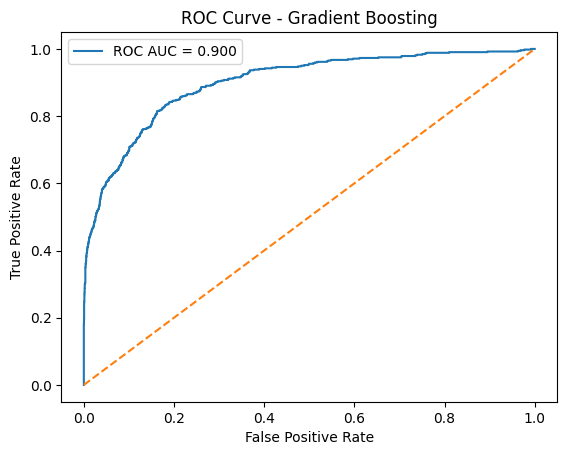

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# probabilities
y_prob = best_gb.predict_proba(X_test_encoded)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

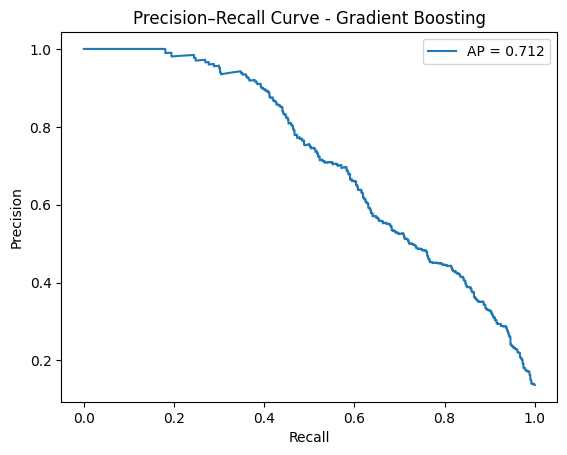

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Gradient Boosting")
plt.legend()
plt.show()

In [55]:
import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "feature": X_train_encoded.columns,
    "importance": best_gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance.head(20))

                            feature  importance
25                   ACCLOC_Unknown    0.035290
147                   PASSENGER_Yes    0.030026
154                   SEASON_Summer    0.027739
155                   SEASON_Winter    0.026859
33          TRAFFCTL_Traffic Signal    0.026757
44           LIGHT_Dark, artificial    0.023597
156         TIME_RANGE_Morning_Rush    0.022565
158       TIME_RANGE_Afternoon_Rush    0.022494
153                   SEASON_Spring    0.021879
14   DISTRICT_Toronto and East York    0.021606
0                        IS_WEEKEND    0.020922
148                    SPEEDING_Yes    0.020652
13             DISTRICT_Scarborough    0.020298
47                   LIGHT_Daylight    0.020289
12              DISTRICT_North York    0.019754
149                     AG_DRIV_Yes    0.019734
159              TIME_RANGE_Evening    0.019342
157                  TIME_RANGE_Day    0.018567
19          ACCLOC_Non Intersection    0.017727
5         ROAD_CLASS_Major Arterial    0

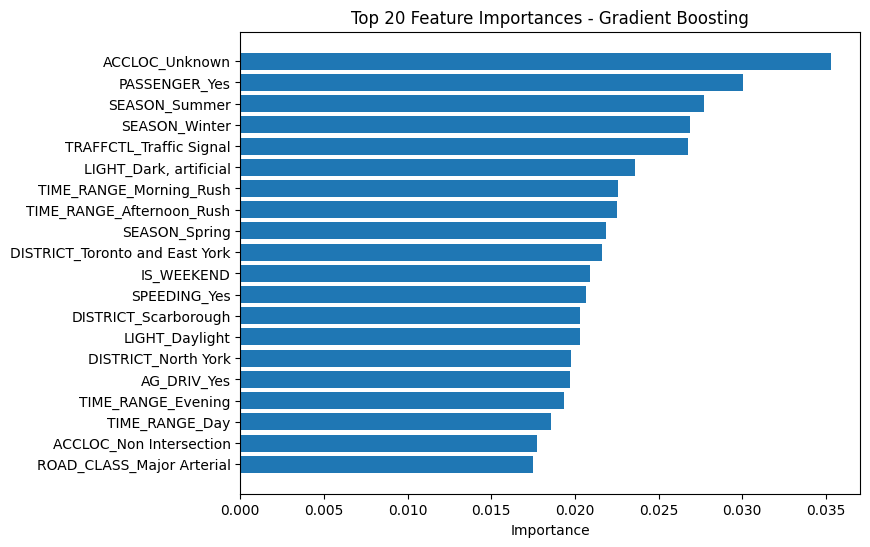

In [56]:
top_features = feature_importance.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances - Gradient Boosting")
plt.show()

In [57]:
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Best model from your tuning
#model = gb_search.best_estimator_

# Compute permutation importance
result = permutation_importance(
    best_gb,
    X_test_encoded,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

# Create dataframe
perm_importance = pd.DataFrame({
    "feature": X_test_encoded.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})

# Sort
perm_importance = perm_importance.sort_values(
    by="importance_mean",
    ascending=False
)

# Top 20
top20 = perm_importance.head(20)

print(top20)

                             feature  importance_mean  importance_std
148                     SPEEDING_Yes         0.139020        0.009752
65   IMPACTYPE_Pedestrian Collisions         0.126024        0.010372
144                        TRUCK_Yes         0.102953        0.008445
14    DISTRICT_Toronto and East York         0.071040        0.006076
147                    PASSENGER_Yes         0.062608        0.008180
13              DISTRICT_Scarborough         0.050453        0.008257
33           TRAFFCTL_Traffic Signal         0.049379        0.006986
47                    LIGHT_Daylight         0.040364        0.007648
140                   PEDESTRIAN_Yes         0.039496        0.008809
0                         IS_WEEKEND         0.038735        0.006739
25                    ACCLOC_Unknown         0.038608        0.004849
149                      AG_DRIV_Yes         0.036406        0.005906
154                    SEASON_Summer         0.035002        0.006889
19           ACCLOC_

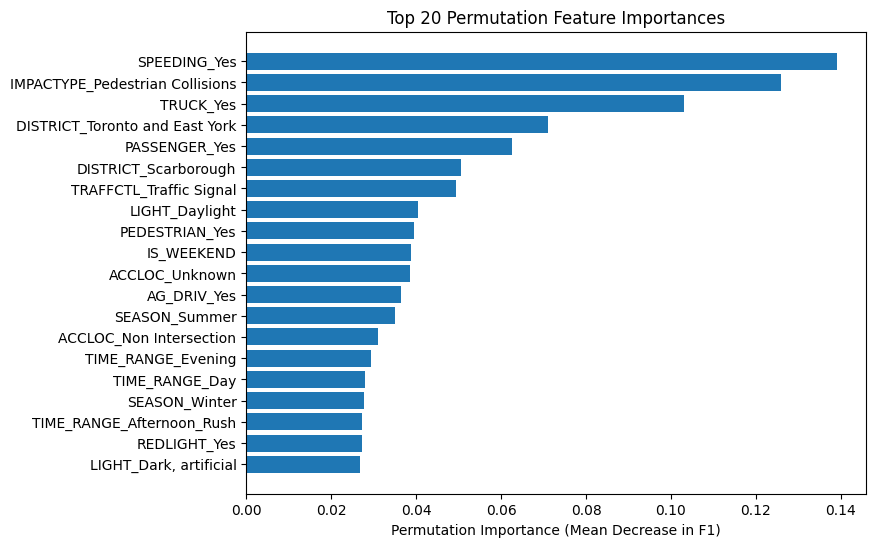

In [58]:
plt.figure(figsize=(8, 6))

plt.barh(
    top20["feature"][::-1],
    top20["importance_mean"][::-1]
)

plt.xlabel("Permutation Importance (Mean Decrease in F1)")
plt.title("Top 20 Permutation Feature Importances")
plt.show()

In [34]:
import pickle

In [35]:
with open("best_gb_model.pkl", "wb") as f:
    pickle.dump(best_gb, f)

In [36]:
import shap

# Create explainer (TreeExplainer is fast for GB models)
explainer = shap.Explainer(best_gb, X_train_encoded)

# Compute SHAP values on test set
shap_values = explainer(X_test_encoded)

Found a NULL input array in _cext_dense_tree_update_weights!


TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_encoded,
    plot_type="bar"
)

In [38]:
X_train_encoded.dtypes.value_counts()

bool     197
int64      1
Name: count, dtype: int64

In [39]:
X_train_shap = X_train_encoded.astype(np.float64)
X_test_shap = X_test_encoded.astype(np.float64)

In [40]:
explainer = shap.TreeExplainer(best_gb)
shap_values = explainer.shap_values(X_test_shap)

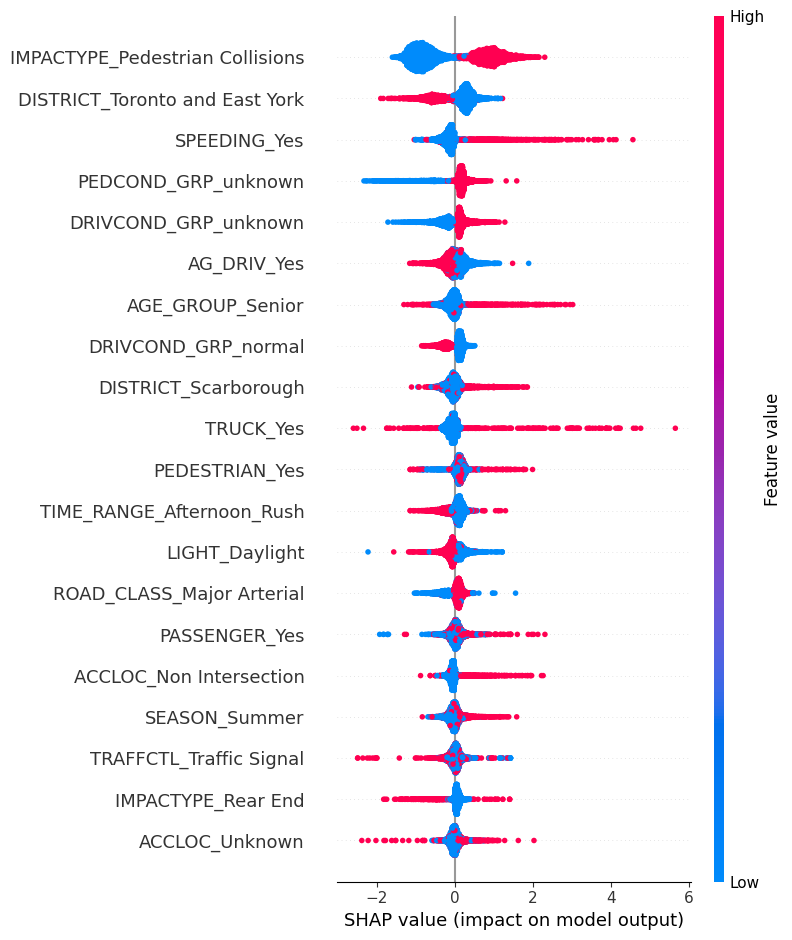

In [41]:
shap.summary_plot(shap_values, X_test_shap, feature_names=X_train_encoded.columns)

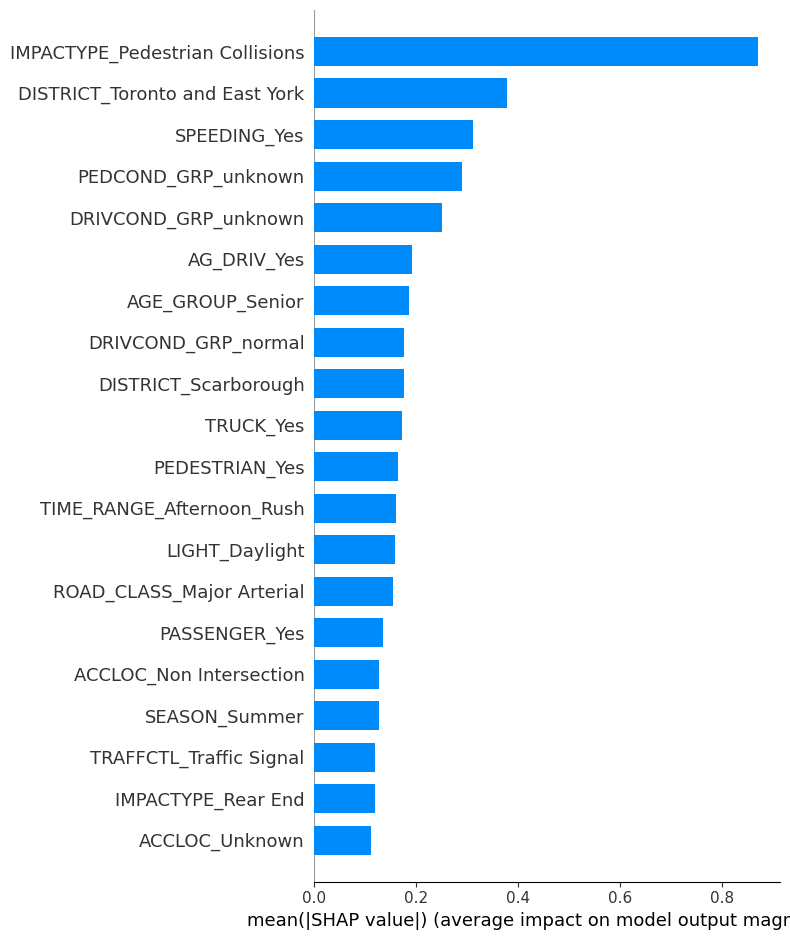

In [45]:
shap.summary_plot(shap_values, X_test_shap, plot_type="bar")

In [46]:
explainer = shap.TreeExplainer(best_gb)

shap_values = explainer(X_test_shap)

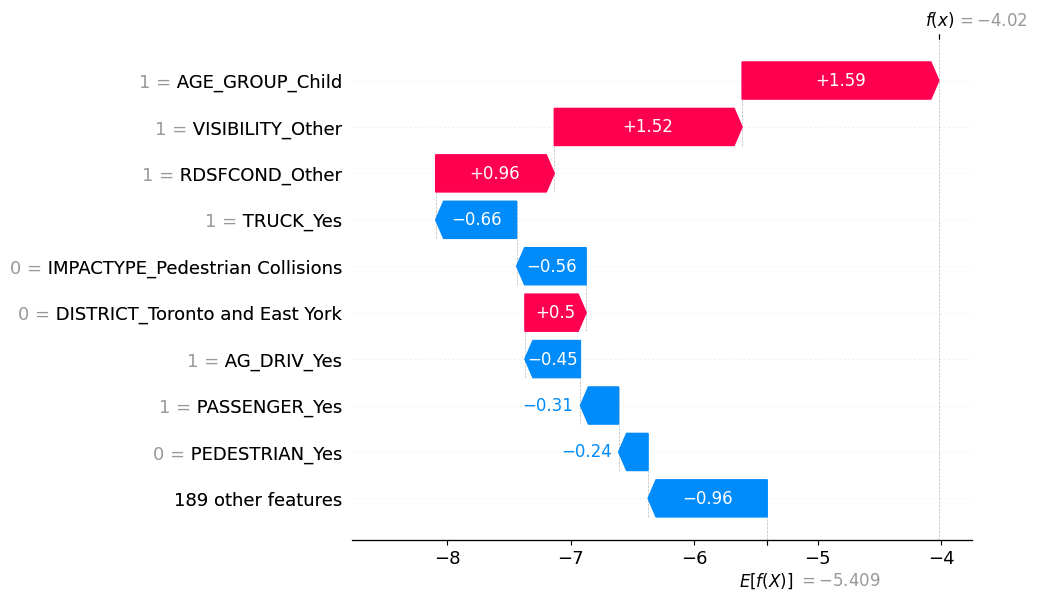

In [48]:
i = 2  # choose row index

shap.plots.waterfall(shap_values[i])

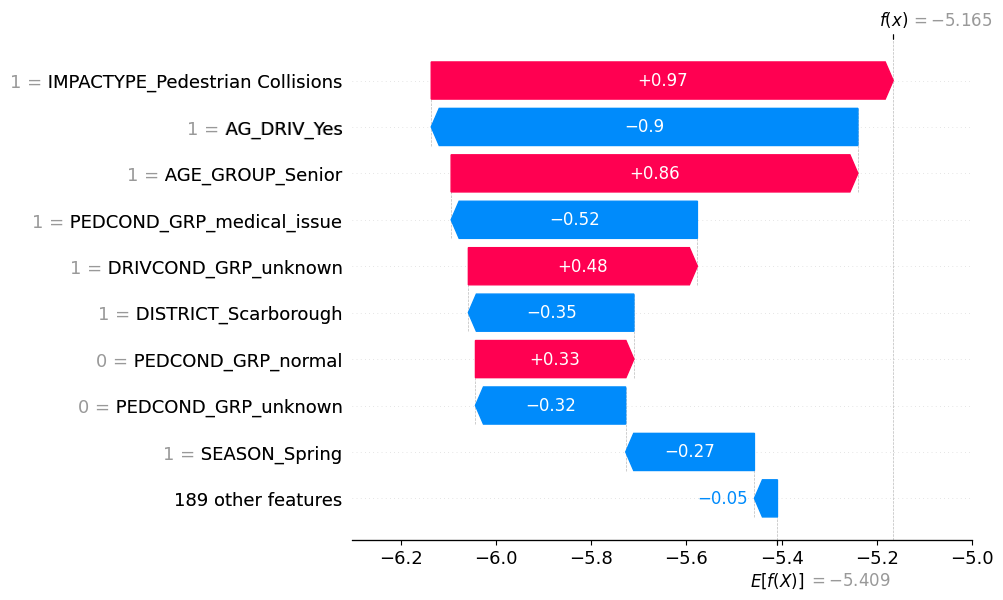

In [49]:
i = 20  # choose row index

shap.plots.waterfall(shap_values[i])

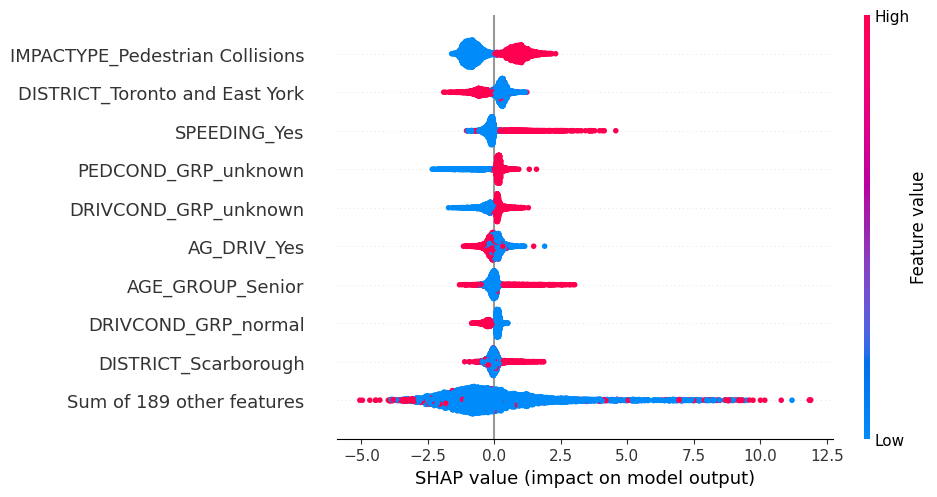

In [50]:
shap.plots.beeswarm(shap_values)